In [ ]:
#All code done by Julia

# 1 just trying on cleaned dataset

I just wanted to test how the random forest model worked on simple features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
feature_cols = [
    'num_chars', 'num_words', 'num_punctuation', 'num_words_uppercase',
    'num_words_lowercase', 'num_stopwords', 'avg_word_len',
    'contain_digits', 'startswith_digits', 'title_sentiment',
    'has_question', 'has_exclamation', 'uppercase_ratio'
]

In [ ]:
X = df[feature_cols]
y = df['view_category_quantile']

# Step 2: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.38      0.37       217
           1       0.19      0.20      0.19       187
           2       0.23      0.23      0.23       198
           3       0.20      0.17      0.19       195
           4       0.23      0.24      0.24       199

    accuracy                           0.25       996
   macro avg       0.24      0.24      0.24       996
weighted avg       0.25      0.25      0.25       996

Confusion Matrix:
 [[83 35 33 36 30]
 [29 37 43 30 48]
 [43 42 45 33 35]
 [35 39 39 34 48]
 [37 42 36 36 48]]


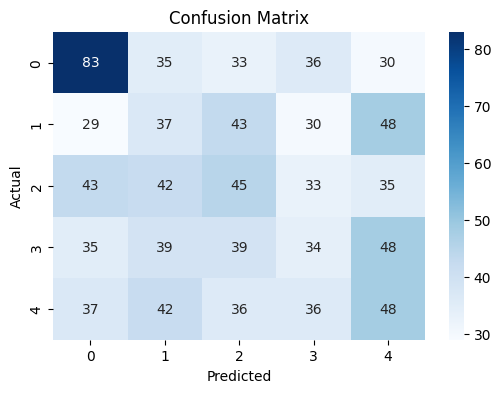

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##Reflection and Goals for Attempt 2

Clearly, this worked really poorly, as the weighted percision and recall averages are .25.

My goals to implement in the second try

1. XGBOOST Algorithim: From here I searched for solutions and found about XGBoost algorithim, or gradient boost algorithim. This algorithim forces the model to build after one another, essentially making multiple smaller models rather than one large model.
2. Reduced complexity compared to regular XGBOOST so as to stop the model from overfitting.
3. Shorter max_depth: less chance of overfitting and lower run time (as the model was taking a very long time before)
4. Take bins/categories down from 5 to 3 -> too hard for the model to predict.

# retry with xgboost

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.32      0.37       332
           1       0.37      0.36      0.37       332
           2       0.37      0.47      0.41       332

    accuracy                           0.39       996
   macro avg       0.39      0.39      0.38       996
weighted avg       0.39      0.39      0.38       996

Confusion Matrix:
 [[107  99 126]
 [ 64 121 147]
 [ 69 106 157]]


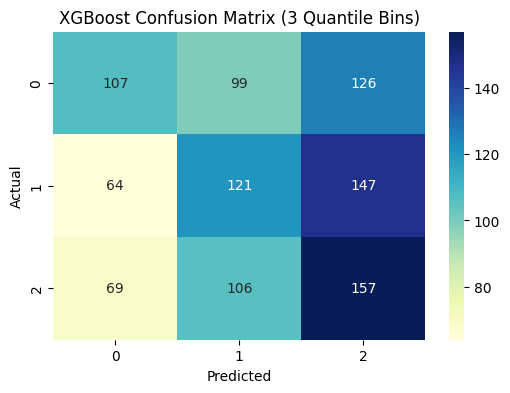

In [ ]:
import xgboost as xgb

# Bin total_views into 3 quantiles
df['view_category_3bin'] = pd.qcut(df['total_views'], q=3, labels=False)

# Features
feature_cols = [
    'num_chars', 'num_words', 'num_punctuation', 'num_words_uppercase',
    'num_words_lowercase', 'num_stopwords', 'avg_word_len',
    'contain_digits', 'startswith_digits', 'title_sentiment',
    'has_question', 'has_exclamation', 'uppercase_ratio'
]

X = df[feature_cols]
y = df['view_category_3bin']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# XGBoost with reduced complexity
clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=50,           # Reduce from 100 to 50
    max_depth=4,               # Shallower trees
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)

# Fit model
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix (3 Quantile Bins)")
plt.show()

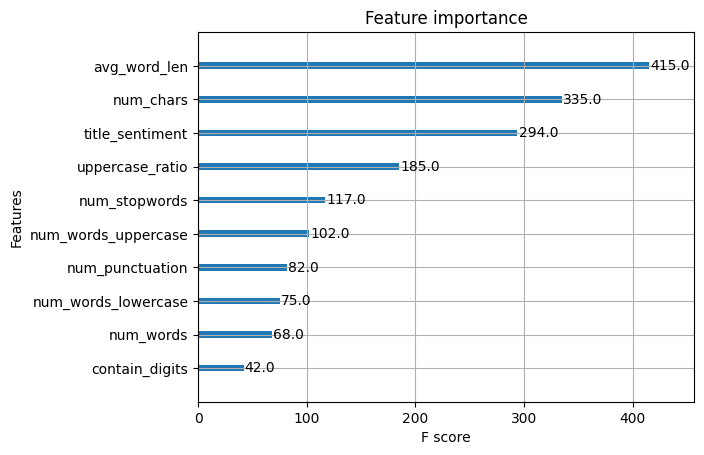

In [ ]:
xgb.plot_importance(clf, max_num_features=10)
plt.show()

##Reflections on Attempt 2
Surprisingly did not work as well as expected, but metrics are up by .20/double compared to before. After this point, I have to do some more in depth problem solving to find out what to change.

From above, I also wanted to see what was the heaviest consideration and found that it was avg_word_length which I believe is not the best predictor to use.

##Goals for Attempt 3
1. Try stacking features
2. Implement TFiDF Vectorizer
3. Implement Sentence Transformers using DistilBERT

# 3 stacking features

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
tfidf_features = vectorizer.fit_transform(df["title_clean"].fillna("")).toarray()

In [ ]:
stylistic_cols = [
    'num_chars', 'num_words', 'num_punctuation', 'num_words_uppercase',
    'num_words_lowercase', 'num_stopwords', 'avg_word_len',
    'contain_digits', 'startswith_digits', 'title_sentiment',
    'has_question', 'has_exclamation', 'uppercase_ratio'
]
stylistic_features = df[stylistic_cols].values

In [ ]:
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.6 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('distilbert-base-uncased')
bert_embeddings = bert_model.encode(df["title_clean"].fillna(""), show_progress_bar=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

In [ ]:
import numpy as np

X = np.hstack([tfidf_features, stylistic_features, bert_embeddings])
y = df['view_category_3bin']

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.48      0.48       332
           1       0.38      0.37      0.37       332
           2       0.40      0.42      0.41       332

    accuracy                           0.42       996
   macro avg       0.42      0.42      0.42       996
weighted avg       0.42      0.42      0.42       996

Confusion Matrix:
 [[158  81  93]
 [ 88 122 122]
 [ 75 116 141]]


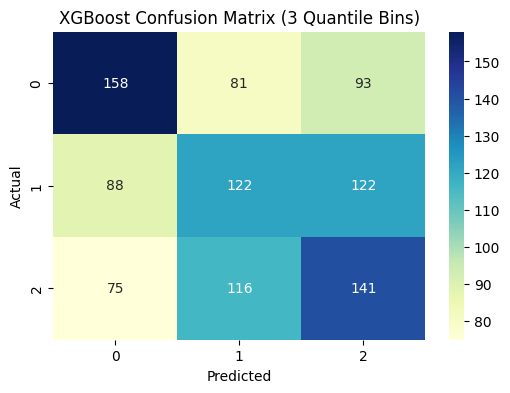

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# XGBoost with reduced complexity
clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=50,           # Reduce from 100 to 50
    max_depth=4,               # Shallower trees
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)

# Fit model
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix (3 Quantile Bins)")
plt.show()

## Reflections on Attempt 3

Worked very Slightly! Major improvements still need to be made, but the run time was much faster.

## Goals for Attempt 4

I wanted to see if maybe the issue was the type of classifier I was using, previously I was using Random Forest Classifier, I want to try to use MLP Classifier and see if that is the issue.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.40      0.50      0.45       332
           1       0.34      0.34      0.34       332
           2       0.43      0.33      0.38       332

    accuracy                           0.39       996
   macro avg       0.39      0.39      0.39       996
weighted avg       0.39      0.39      0.39       996



## Reflection on Attempt 4
The change in classifier is actually worse, so I am reverting back to using Random Forest.

## Goals for Attempt 5
1. Test to see if the issue is the type of BERT, originally test using uncased BERT.

In [ ]:
bert_model_cased = SentenceTransformer('distilbert-base-uncased')
bert_embeddings_uncased = bert_model.encode(df["title_clean"].fillna(""), show_progress_bar=True)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

In [ ]:
X = np.hstack([tfidf_features, stylistic_features, bert_embeddings_uncased])
y = df['view_category_3bin']

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.43      0.44       332
           1       0.38      0.37      0.37       332
           2       0.43      0.46      0.45       332

    accuracy                           0.42       996
   macro avg       0.42      0.42      0.42       996
weighted avg       0.42      0.42      0.42       996

Confusion Matrix:
 [[144  98  90]
 [ 97 122 113]
 [ 79  99 154]]


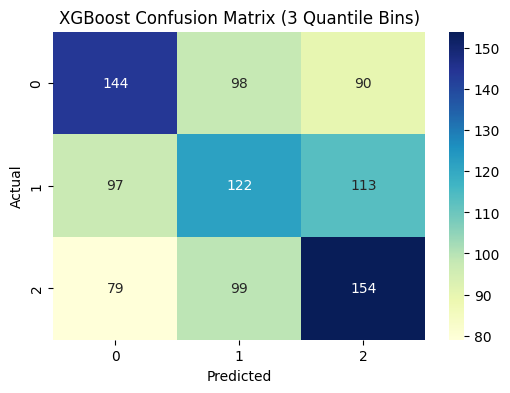

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# XGBoost with reduced complexity
clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=50,           # Reduce from 100 to 50
    max_depth=4,               # Shallower trees
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)

# Fit model
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix (3 Quantile Bins)")
plt.show()

In [ ]:
# Redo train/test split and track index
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df.index, test_size=0.2, stratify=y, random_state=42)

# Fit model (reuse your MLP, LogisticRegression, etc.)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Identify misclassified indices
import numpy as np
misclassified_idx = test_idx[np.where(y_test != y_pred)[0]]

# View original misclassified rows
misclassified = df.loc[misclassified_idx]
misclassified[['title_original', 'total_views', 'view_category_3bin']].head()

,title_original,total_views,view_category_3bin
4362,6 AMAZING AND EASY DIY SPINNERS || CANDLE FIDG...,1286539,1
986,25 CRAZY FURNITURE RENOVATION HACKS,1160761,1
3912,30 DELICIOUS 5-MINUTE RECIPES,16585430,2
902,27 LIP ARTS TO TRY RIGHT NOW,419439,0
2399,25 AMAZING DIY IDEAS FOR YOU,2038040,1


## Reflection on Attempt 5

The Random Forest Classifier does work better, but the current run was not any better than the previous Random Forest run (Attempt 3). To remedy this, I did some more discovery on what exactly was getting misclassified to see what the issue is, saw that the ones getting misclassified had all caps used. Based off of this I realized that maybe it would be useful to implement the cased BERT.

## Goals for Attempt 6
1. Implement using CASED BERT for sentence embeddings
2. Add more unique stylistic features, going into more of the content of the text used rather than just its metadata.

In [ ]:
bert_model_cased = SentenceTransformer('distilbert-base-cased')
bert_embeddings_cased = bert_model.encode(df["title_original"].fillna(""), show_progress_bar=True)

In [ ]:
for word in ['hack', 'trick', 'recipe', 'easy', 'amazing', 'tutorial', 'life']:
    df[f'contains_{word}'] = df['title_clean'].str.contains(word).astype(int)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['title_clean'])

km = KMeans(n_clusters=10, random_state=42)
df['tfidf_cluster'] = km.fit_predict(X_tfidf)

In [ ]:
df['unique_word_ratio'] = df['title_clean'].apply(lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0)


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
df['num_nouns'] = df['title_clean'].apply(lambda x: sum(1 for t in nlp(x) if t.pos_ == 'NOUN'))

In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.7 MB/s eta 0:00:00


In [ ]:
import textstat
df['readability'] = df['title_clean'].apply(lambda x: textstat.flesch_reading_ease(x))

In [ ]:
df.head()

,title_original,title_clean,active_since_days,duration_seconds,total_views,views_by_day,view_category_quantile,num_chars,num_words,num_punctuation,...,contains_trick,contains_recipe,contains_easy,contains_amazing,contains_tutorial,contains_life,tfidf_cluster,unique_word_ratio,num_nouns,readability
0,SUPER LAZY LIFE HACKS || Cool Hacks To Make Yo...,super lazy life hacks cool hacks to make your ...,22,623,295614,13437,0,60,12,2,...,0,0,0,0,0,1,9,0.818182,4,77.23
1,YUM! EASY SMART FOOD HACKS || Tasty Recipes Fo...,yum easy smart food hacks tasty recipes for th...,1,739,130544,130544,0,87,17,4,...,0,1,1,0,0,0,8,1.000000,6,56.25
2,HELPFUL LIFE HACKS FOR YOUR HOUSE,helpful life hacks for your house,1,960,17834,17834,0,33,6,0,...,0,0,0,0,0,1,8,1.000000,3,99.23
3,USEFUL HACKS FOR YOUR HOME || Simple Tips That...,useful hacks for your home simple tips that wo...,30,833,3128867,104295,3,66,12,2,...,0,0,0,0,0,0,1,1.000000,3,77.23
4,ARE YOU A CRAFTY MOM? Amazing Parenting Hacks ...,are you a crafty mom amazing parenting hacks a...,15,3600,4210362,280690,3,56,10,1,...,0,0,0,1,0,0,5,1.000000,4,69.79


In [ ]:
y = df['view_category_3bin']

drop_cols = [
    'title_original', 'title_clean', 'title_tokens', 'title_lemmas',
    'total_views', 'view_category_quantile', 'view_category_3bin'
]

X = df.drop(columns=drop_cols)

In [ ]:
X.head()

,active_since_days,duration_seconds,views_by_day,num_chars,num_words,num_punctuation,num_words_uppercase,num_words_lowercase,num_stopwords,avg_word_len,...,contains_trick,contains_recipe,contains_easy,contains_amazing,contains_tutorial,contains_life,tfidf_cluster,unique_word_ratio,num_nouns,readability
0,22,623,13437,60,12,2,4,0,2,5.000000,...,0,0,0,0,0,1,9,0.818182,4,77.23
1,1,739,130544,87,17,4,5,0,3,5.117647,...,0,1,1,0,0,0,8,1.000000,6,56.25
2,1,960,17834,33,6,0,6,0,2,5.500000,...,0,0,0,0,0,1,8,1.000000,3,99.23
3,30,833,104295,66,12,2,5,0,3,5.500000,...,0,0,0,0,0,0,1,1.000000,3,77.23
4,15,3600,280690,56,10,1,5,0,4,5.600000,...,0,0,0,1,0,0,5,1.000000,4,69.79


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       332
           1       0.89      0.89      0.89       332
           2       0.96      0.95      0.95       332

    accuracy                           0.93       996
   macro avg       0.93      0.93      0.93       996
weighted avg       0.93      0.93      0.93       996



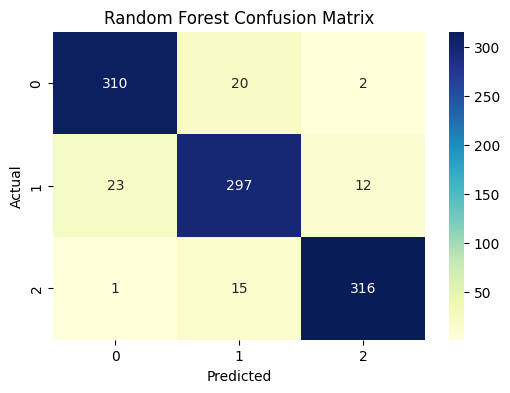

In [ ]:
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

##Reflection for Attempt 6

After Implementing
1. BERT CASED model
2. contain words (eye-catching words: ['hack', 'trick', 'recipe', 'easy', 'amazing', 'tutorial', 'life'] )
3. P.O.S tagging
4. TFiDF vectorization
5. Readability score using Flesch Reading Ease Formula
6. Getting rid of the more basic feature engineering

The model works a lot better now the average percision and recall is at .94 compared to the .42s of before. As it has hit the 90s parameters, I decided to switch over to making the demo.

#making the demo

First I just got the neccessary packages (gradio and joblib) to create the groundwork for the rest of the demo.

In [ ]:
!pip install -q gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.6 MB/s eta 0:00:00


In [ ]:
feature_columns = X.columns.tolist()

In [ ]:
import joblib

# Save your model and any vectorizers/preprocessors
joblib.dump(clf, 'model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')         # if using TF-IDF
joblib.dump(feature_columns, 'feature_columns.pkl')     # column list for consistency

['feature_columns.pkl']

# Create methods to pass the model to the demo.

all tf_idf features and pre-processing are applied to the dataset, and a stack is created with all the different features which is passed through the model

In [ ]:
def extract_features(title):
    cleaned = clean_text(title)
    tfidf_vec = vectorizer.transform([cleaned]).toarray()

    # Rebuild ALL features used during training
    features = {
        'num_chars': len(title),
        'num_words': len(title.split()),
        'has_question': int('?' in title),
        'has_exclamation': int('!' in title),
        'uppercase_ratio': sum(c.isupper() for c in title) / len(title) if len(title) > 0 else 0,
        'contains_number': int(bool(re.search(r'\d', title))),
        'swear_word_count': sum(1 for w in title.lower().split() if w in {'damn', 'hell', 'crap', 'shit', 'fuck'}),
        'avg_word_len': np.mean([len(w) for w in title.split()]) if len(title.split()) > 0 else 0,
    }

    handcrafted = np.array([features[k] for k in sorted(features)]).reshape(1, -1)

    combined = np.hstack([tfidf_vec, handcrafted])
    return pd.DataFrame(combined, columns=feature_columns)

#Using gradio to make the demo

After loading the saved model from importing joblib, I created various functions like clean text and extract_features and predict_view_category using the model.

I called predict_view_category within the gradio interface which allows the user to input clickbait on their own end.

I also added the ability for users to add more data on their own, as originally gradio was setting these values to 0, the data that users can add include Video (Title), Video Duration (Seconds), Active Since (Days), and Views Per Day.

In [ ]:
import gradio as gr
import joblib
import pandas as pd
import numpy as np
import re

# Load your saved components
model = joblib.load("model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

# Feature extraction function
def extract_features(title, duration_seconds, active_days, views_by_day):
    cleaned = clean_text(title)

    features = {
        'active_since_days': active_days,
        'duration_seconds': duration_seconds,
        'views_by_day': views_by_day,
        'num_chars': len(title),
        'num_words': len(title.split()),
        'num_punctuation': sum(1 for c in title if c in ".,!?"),
        'num_words_uppercase': sum(1 for w in title.split() if w.isupper()),
        'num_words_lowercase': sum(1 for w in title.split() if w.islower()),
        'num_stopwords': sum(1 for w in title.lower().split() if w in {'the', 'and', 'a', 'to', 'in', 'for', 'with'}),
        'avg_word_len': np.mean([len(w) for w in title.split()]) if title.split() else 0,
        'contain_digits': int(any(c.isdigit() for c in title)),
        'startswith_digits': int(title[0].isdigit()) if len(title) > 0 else 0,
        'title_sentiment': 0,  # optional, placeholder
        'has_question': int('?' in title),
        'has_exclamation': int('!' in title),
        'uppercase_ratio': sum(1 for c in title if c.isupper()) / len(title) if len(title) > 0 else 0,
        'capital_count': sum(1 for c in title if c.isupper()),
        'swear_word_count': sum(1 for w in title.lower().split() if w in {'damn', 'hell', 'crap', 'shit', 'fuck'}),
        'contains_hack': int('hack' in cleaned),
        'contains_trick': int('trick' in cleaned),
        'contains_recipe': int('recipe' in cleaned),
        'contains_easy': int('easy' in cleaned),
        'contains_amazing': int('amazing' in cleaned),
        'contains_tutorial': int('tutorial' in cleaned),
        'contains_life': int('life' in cleaned),
        'tfidf_cluster': 0,  # optional placeholder
        'unique_word_ratio': len(set(title.split())) / len(title.split()) if title.split() else 0,
        'num_nouns': 0,  # optional placeholder
        'readability': 0  # optional placeholder
    }

    return pd.DataFrame([[features.get(col, 0) for col in feature_columns]], columns=feature_columns)

# Prediction function
def predict_view_category(title, duration_seconds, active_days, views_by_day):
    features = extract_features(title, duration_seconds, active_days, views_by_day)
    pred = model.predict(features)[0]
    prob = model.predict_proba(features)[0]

    labels = {0: "Low", 1: "Medium", 2: "High"}
    return f"Predicted View Category: {labels[pred]} (Class {pred})", {
        "Low": prob[0],
        "Medium": prob[1],
        "High": prob[2]
    }

    return f"Predicted View Category: **{labels[pred]}** (Class {pred})", confidence_dict
# Gradio interface

demo = gr.Interface(
    fn=predict_view_category,
    inputs=[
        gr.Textbox(label="Video Title"),
        gr.Number(label="Duration (seconds)", value=300),
        gr.Number(label="Active Since (days)", value=30),
        gr.Number(label="Views per Day", value=10000),
    ],
    outputs=[
        gr.Text(label="Prediction"),
        gr.Label(num_top_classes=3, label="Confidence Scores")
    ],
    title="YouTube Title View Predictor",
    description="Enter a video title and metadata to predict how well it will perform (low, medium, or high)."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c3ed16147519cf2394.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
feature_columns[]


['active_since_days',
 'duration_seconds',
 'views_by_day',
 'num_chars',
 'num_words',
 'num_punctuation',
 'num_words_uppercase',
 'num_words_lowercase',
 'num_stopwords',
 'avg_word_len',
 'contain_digits',
 'startswith_digits',
 'title_sentiment',
 'has_question',
 'has_exclamation',
 'uppercase_ratio',
 'capital_count',
 'swear_word_count',
 'contains_hack',
 'contains_trick',
 'contains_recipe',
 'contains_easy',
 'contains_amazing',
 'contains_tutorial',
 'contains_life',
 'tfidf_cluster',
 'unique_word_ratio',
 'num_nouns',
 'readability']